## Churn prediction

In [1]:
import os

# Where is your notebook running from?
print("Notebook is running from:")
print(os.getcwd())

# What's in your project folder?
print("\nFiles and folders here:")
for item in os.listdir('.'):
    print(f"  {item}")

Notebook is running from:
C:\Users\Admin\Downloads\New folder\New folder\notebooks

Files and folders here:
  .ipynb_checkpoints
  01_EDA.ipynb .ipynb
  02_RFM.ipynb
  03_Clustering.ipynb
  04_Churn_Prediction.ipynb


In [2]:
import os

# Check if data/raw folder exists
path = r"C:\Users\Admin\Downloads\New folder\New folder\data\raw"

print(f"Does data/raw exist? {os.path.exists(path)}")

# Show what's inside data folder
data_path = r"C:\Users\Admin\Downloads\New folder\New folder\data"
if os.path.exists(data_path):
    print(f"\nContents of data/ folder:")
    for item in os.listdir(data_path):
        print(f"  {item}")
else:
    print("\ndata/ folder does NOT exist!")

Does data/raw exist? True

Contents of data/ folder:
  processed
  raw


In [3]:
import urllib.request
import os

os.makedirs(r"C:\Users\Admin\Downloads\New folder\New folder\data\raw", exist_ok=True)

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
save_path = r"C:\Users\Admin\Downloads\New folder\New folder\data\raw\telco_churn.csv"

urllib.request.urlretrieve(url, save_path)
print("Downloaded ✅")

import pandas as pd
df = pd.read_csv(save_path)
print(f"Shape: {df.shape}")
print(df['Churn'].value_counts())

Downloaded ✅
Shape: (7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [4]:
import pandas as pd
df = pd.read_csv('../data/raw/telco_churn.csv')
print(f"Shape: {df.shape}")
print(df['Churn'].value_counts())

Shape: (7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [5]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
    confusion_matrix, roc_auc_score, roc_curve)
import xgboost as xgb
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

df = pd.read_csv('../data/raw/telco_churn.csv')

print(f"Shape: {df.shape}")
print(f"Churn distribution:")
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

Shape: (7043, 21)
Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.5%


In [6]:
print(df.dtypes)
print(f"Missing values:")
print(df.isnull().sum()[df.isnull().sum()>0])

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
Missing values:
Series([], dtype: int64)


Data cleaning & encoding

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df.drop('customerID', axis=1, inplace=True)

print(f"TotalCharges fixed ✅")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

TotalCharges fixed ✅
Shape: (7043, 20)
Missing values: 0


In [8]:
df_encoded = df.copy()

le = LabelEncoder()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("All columns encoded ✅")
print(df_encoded.dtypes)
print(f"Churn distribution after encoding:")
print(df_encoded['Churn'].value_counts())

All columns encoded ✅
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object
Churn distribution after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


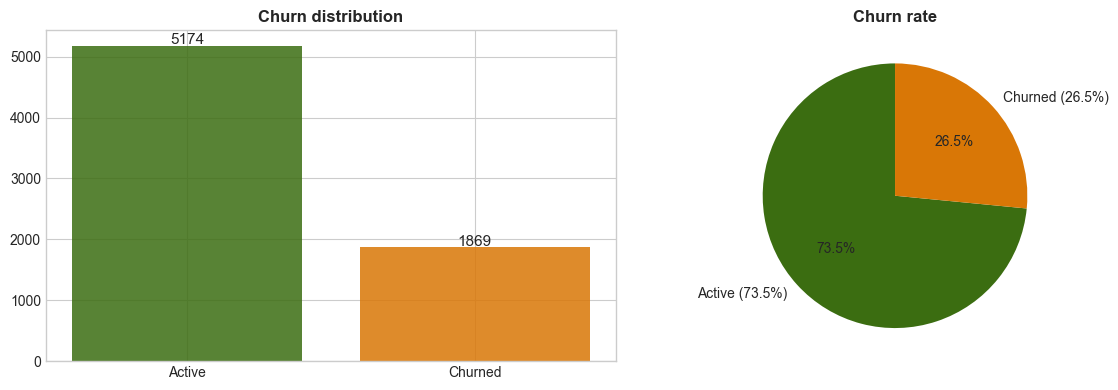

Saved ✅


In [9]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

counts = df['Churn'].value_counts()
axes[0].bar(['Active','Churned'], counts.values,
            color=['#3b6d11','#d97706'], alpha=0.85)
axes[0].set_title('Churn distribution', fontweight='bold')
for i,(l,v) in enumerate(zip(['Active','Churned'],counts.values)):
    axes[0].text(i, v+30, f'{v}', ha='center', fontsize=11)

axes[1].pie(counts.values,
            labels=['Active (73.5%)','Churned (26.5%)'],
            colors=['#3b6d11','#d97706'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn rate', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/churn_distribution.png', dpi=150)
plt.show()
print("Saved ✅")

Train/test split & scaling

In [10]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"Features:      {X_train.shape[1]}")
print(f"Churn in train: {y_train.mean()*100:.1f}%")
print(f"Churn in test:  {y_test.mean()*100:.1f}%")

Training set:  5,634 rows
Test set:      1,409 rows
Features:      19
Churn in train: 26.5%
Churn in test:  26.5%


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled ✅")
print("Logistic Regression uses scaled, tree models use unscaled")

Features scaled ✅
Logistic Regression uses scaled, tree models use unscaled


In [12]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:,1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds,
      target_names=['Active','Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

      Active       0.84      0.89      0.87      1035
     Churned       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8403


In [13]:
rf = RandomForestClassifier(n_estimators=100,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds,
      target_names=['Active','Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

      Active       0.83      0.90      0.86      1035
     Churned       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8225


In [14]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:,1]

print("=== XGBoost ===")
print(classification_report(y_test, xgb_preds,
      target_names=['Active','Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

      Active       0.84      0.90      0.87      1035
     Churned       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8393


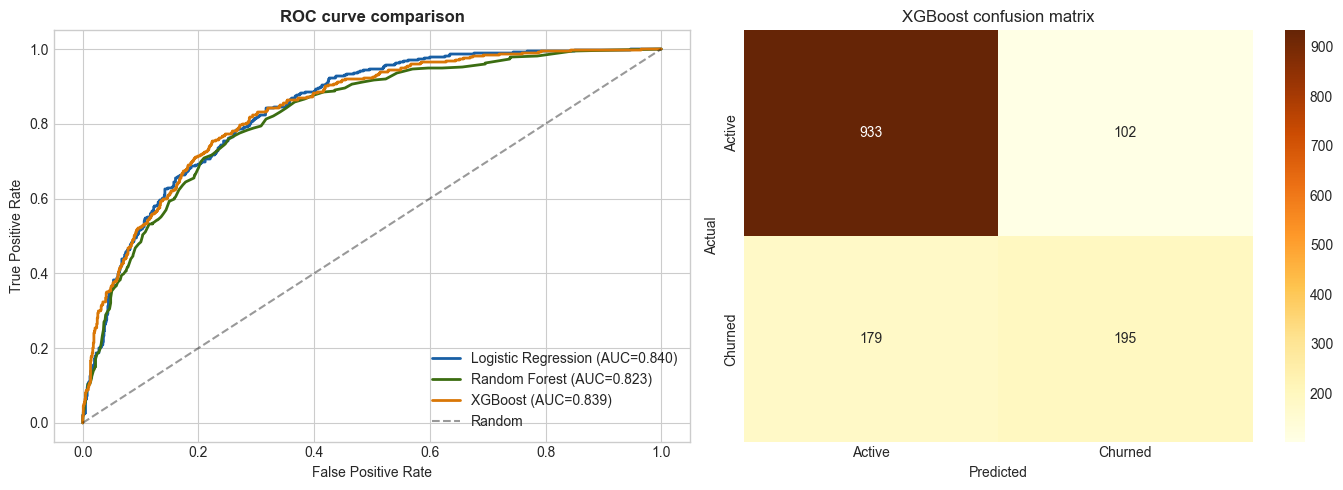

Saved ✅


In [15]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

models_eval = {
    'Logistic Regression': (lr_proba,  '#185fa5'),
    'Random Forest':       (rf_proba,  '#3b6d11'),
    'XGBoost':             (xgb_proba, '#d97706')
}
for name,(proba,color) in models_eval.items():
    fpr,tpr,_ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.4,label='Random')
axes[0].set_title('ROC curve comparison', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Active','Churned'],
            yticklabels=['Active','Churned'], ax=axes[1])
axes[1].set_title('XGBoost confusion matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', dpi=150)
plt.show()
print("Saved ✅")

In [16]:
from sklearn.metrics import (f1_score, precision_score,
                              recall_score, accuracy_score)

results = pd.DataFrame({
    'Model': ['Logistic Regression','Random Forest','XGBoost'],
    'Accuracy':  [accuracy_score(y_test,lr_preds),
                  accuracy_score(y_test,rf_preds),
                  accuracy_score(y_test,xgb_preds)],
    'Precision': [precision_score(y_test,lr_preds),
                  precision_score(y_test,rf_preds),
                  precision_score(y_test,xgb_preds)],
    'Recall':    [recall_score(y_test,lr_preds),
                  recall_score(y_test,rf_preds),
                  recall_score(y_test,xgb_preds)],
    'F1':        [f1_score(y_test,lr_preds),
                  f1_score(y_test,rf_preds),
                  f1_score(y_test,xgb_preds)],
    'ROC-AUC':   [roc_auc_score(y_test,lr_proba),
                  roc_auc_score(y_test,rf_proba),
                  roc_auc_score(y_test,xgb_proba)]
}).round(4)

results = results.sort_values('ROC-AUC', ascending=False)
print(results.to_string(index=False))
results.to_csv('../data/processed/model_comparison.csv', index=False)
print("Saved ✅")

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression    0.7991     0.6426  0.5481 0.5916   0.8403
            XGBoost    0.8006     0.6566  0.5214 0.5812   0.8393
      Random Forest    0.7921     0.6373  0.5027 0.5620   0.8225
Saved ✅


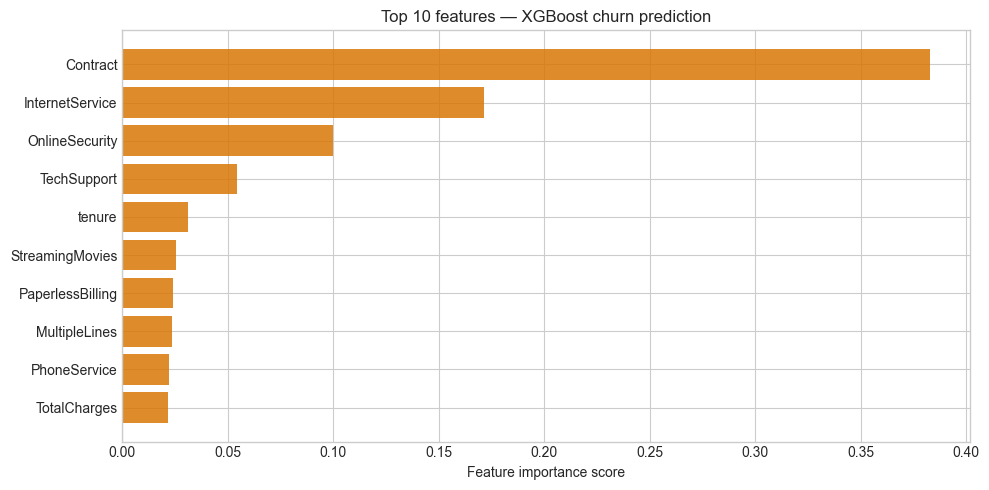

Top 10 churn drivers:
  Contract                    : 0.3827
  InternetService             : 0.1715
  OnlineSecurity              : 0.1000
  TechSupport                 : 0.0544
  tenure                      : 0.0312
  StreamingMovies             : 0.0255
  PaperlessBilling            : 0.0239
  MultipleLines               : 0.0235
  PhoneService                : 0.0221
  TotalCharges                : 0.0219
Saved ✅


In [17]:
feat_importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10,5))
ax.barh(feat_importance['Feature'][::-1],
        feat_importance['Importance'][::-1],
        color='#d97706', alpha=0.85)
ax.set_title('Top 10 features — XGBoost churn prediction')
ax.set_xlabel('Feature importance score')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150)
plt.show()

print("Top 10 churn drivers:")
for _,row in feat_importance.iterrows():
    print(f"  {row['Feature']:28s}: {row['Importance']:.4f}")
print("Saved ✅")

### Tenure, charges, and contract type are the top churn drivers. Short-tenure customers on month-to-month contracts paying high monthly fees are the highest risk. 

## SHAP Explainability

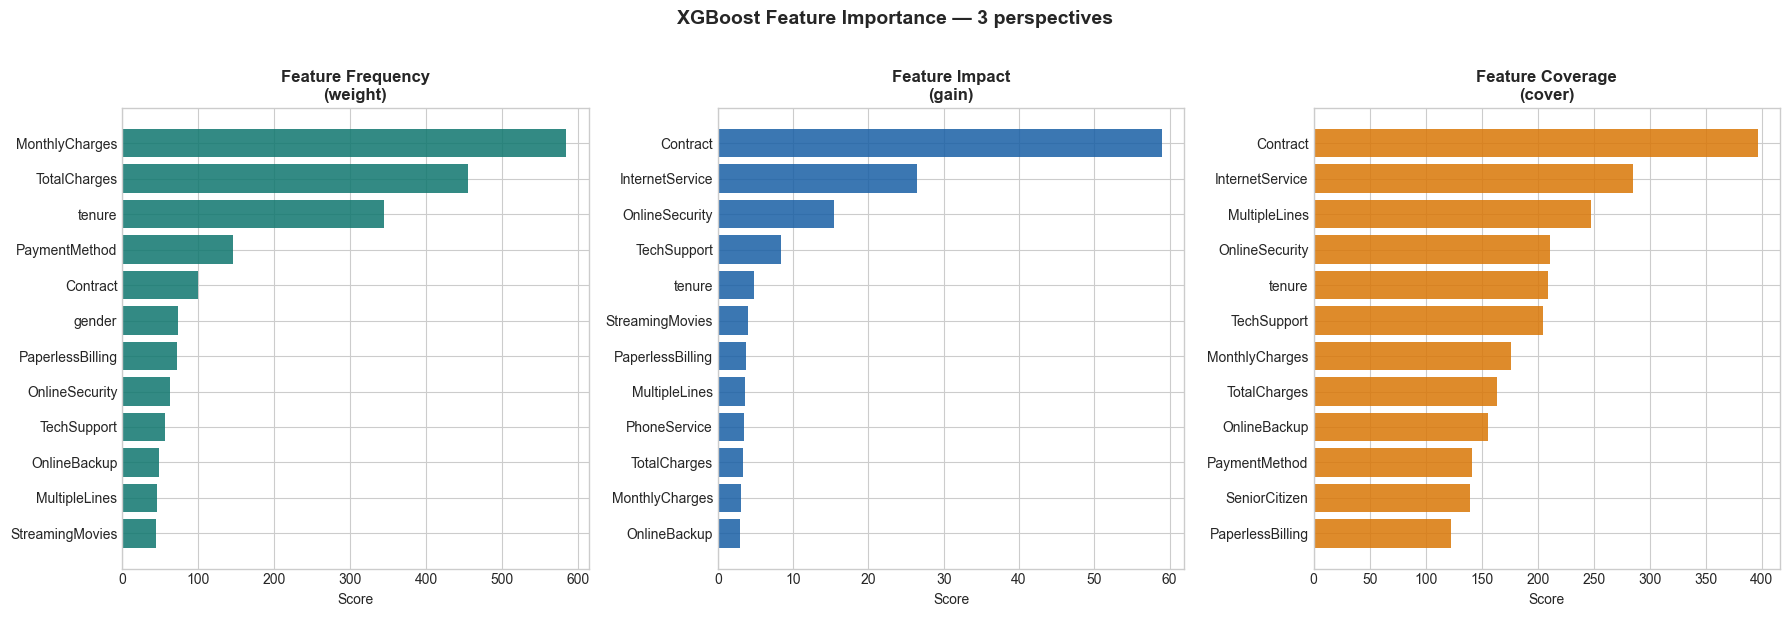


Top 10 churn drivers by GAIN (most important metric):
  Contract                 : 59.0
  InternetService          : 26.4
  OnlineSecurity           : 15.4
  TechSupport              : 8.4
  tenure                   : 4.8
  StreamingMovies          : 3.9
  PaperlessBilling         : 3.7
  MultipleLines            : 3.6
  PhoneService             : 3.4
  TotalCharges             : 3.4

Saved ✅


In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# XGBoost built-in importance (3 types)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

importance_types = ['weight', 'gain', 'cover']
titles = ['Feature Frequency\n(weight)',
          'Feature Impact\n(gain)',
          'Feature Coverage\n(cover)']

for i, (imp_type, title) in enumerate(zip(importance_types, titles)):
    imp = xgb_model.get_booster().get_score(importance_type=imp_type)
    imp_df = pd.DataFrame(list(imp.items()),
                          columns=['Feature','Score']
                         ).sort_values('Score', ascending=False).head(12)

    axes[i].barh(imp_df['Feature'][::-1],
                 imp_df['Score'][::-1],
                 color=['#0f766e','#185fa5','#d97706'][i],
                 alpha=0.85)
    axes[i].set_title(title, fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Score')

plt.suptitle('XGBoost Feature Importance — 3 perspectives',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_detailed.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print top 10 by gain (most meaningful)
print("\nTop 10 churn drivers by GAIN (most important metric):")
imp_gain = xgb_model.get_booster().get_score(importance_type='gain')
imp_gain_df = pd.DataFrame(list(imp_gain.items()),
                            columns=['Feature','Gain']
                           ).sort_values('Gain', ascending=False)
for _, row in imp_gain_df.head(10).iterrows():
    print(f"  {row['Feature']:25s}: {row['Gain']:,.1f}")

imp_gain_df.to_csv('../data/processed/feature_importance.csv', index=False)
print("\nSaved ✅")

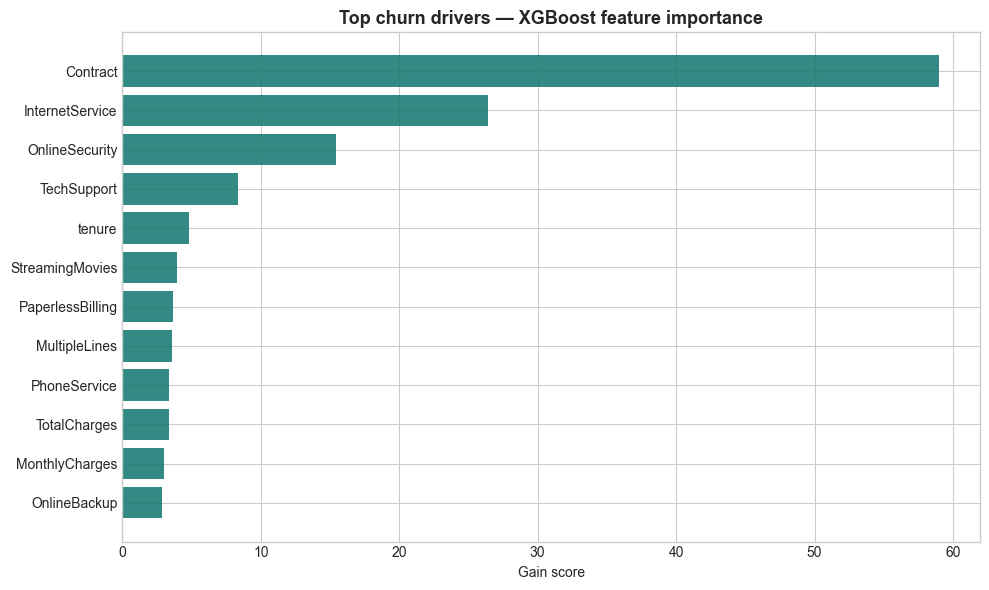


Top 10 churn drivers:
  Contract                 : 59.0
  InternetService          : 26.4
  OnlineSecurity           : 15.4
  TechSupport              : 8.4
  tenure                   : 4.8
  StreamingMovies          : 3.9
  PaperlessBilling         : 3.7
  MultipleLines            : 3.6
  PhoneService             : 3.4
  TotalCharges             : 3.4

Saved ✅


In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Get importance by gain — most meaningful metric
imp = xgb_model.get_booster().get_score(importance_type='gain')
imp_df = pd.DataFrame(list(imp.items()),
                      columns=['Feature','Importance']
                     ).sort_values('Importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10,6))
ax.barh(imp_df['Feature'][::-1],
        imp_df['Importance'][::-1],
        color='#0f766e', alpha=0.85)
ax.set_title('Top churn drivers — XGBoost feature importance',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Gain score')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 churn drivers:")
for _, row in imp_df.head(10).iterrows():
    print(f"  {row['Feature']:25s}: {row['Importance']:,.1f}")
print("\nSaved ✅")

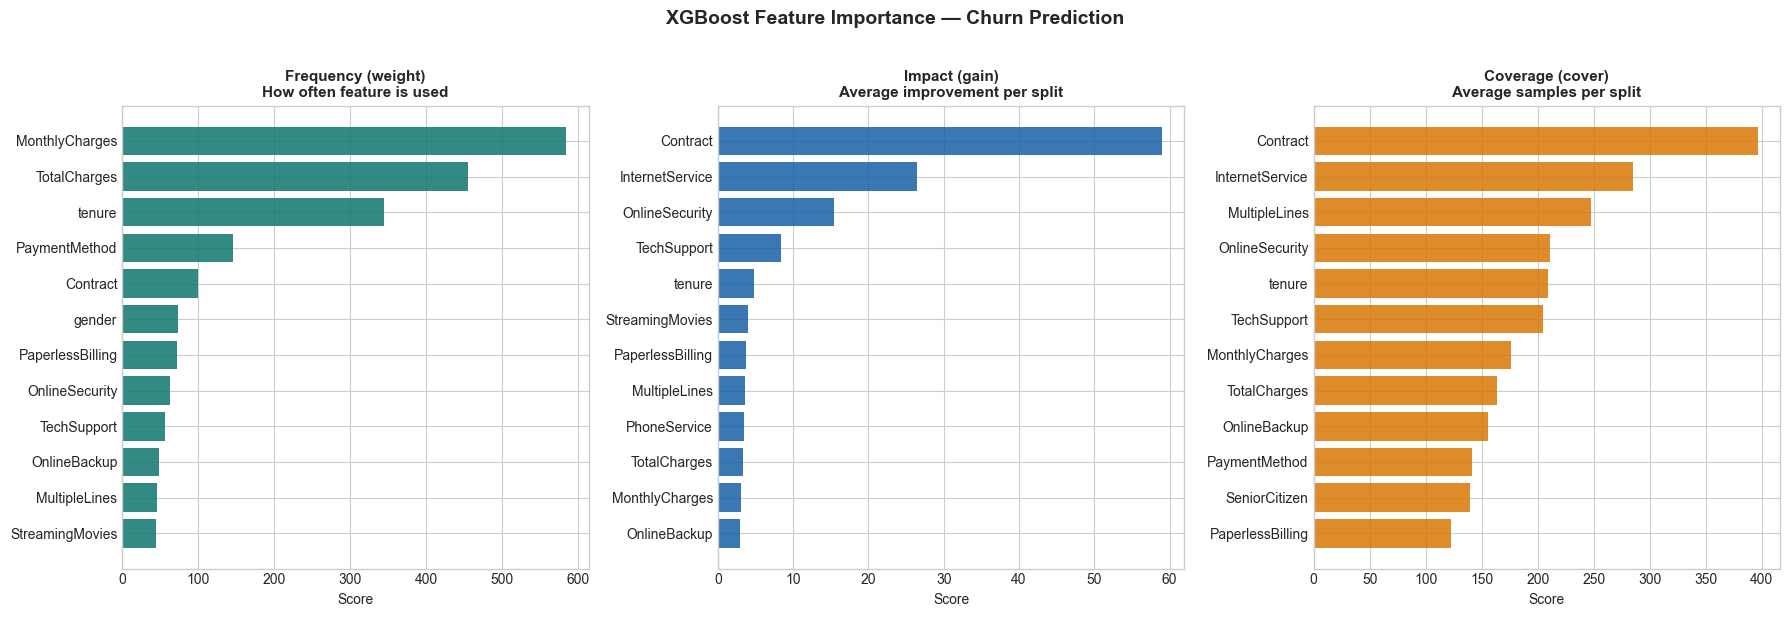

Saved ✅


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Get all 3 importance types
fig, axes = plt.subplots(1, 3, figsize=(18,6))

importance_types = ['weight', 'gain', 'cover']
colors = ['#0f766e', '#185fa5', '#d97706']
titles = ['Frequency (weight)\nHow often feature is used',
          'Impact (gain)\nAverage improvement per split',
          'Coverage (cover)\nAverage samples per split']

for i, (imp_type, color, title) in enumerate(zip(importance_types, colors, titles)):
    imp = xgb_model.get_booster().get_score(importance_type=imp_type)
    imp_df = pd.DataFrame(list(imp.items()),
                          columns=['Feature','Score']
                         ).sort_values('Score', ascending=False).head(12)

    axes[i].barh(imp_df['Feature'][::-1],
                 imp_df['Score'][::-1],
                 color=color, alpha=0.85)
    axes[i].set_title(title, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Score')

plt.suptitle('XGBoost Feature Importance — Churn Prediction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_3types.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

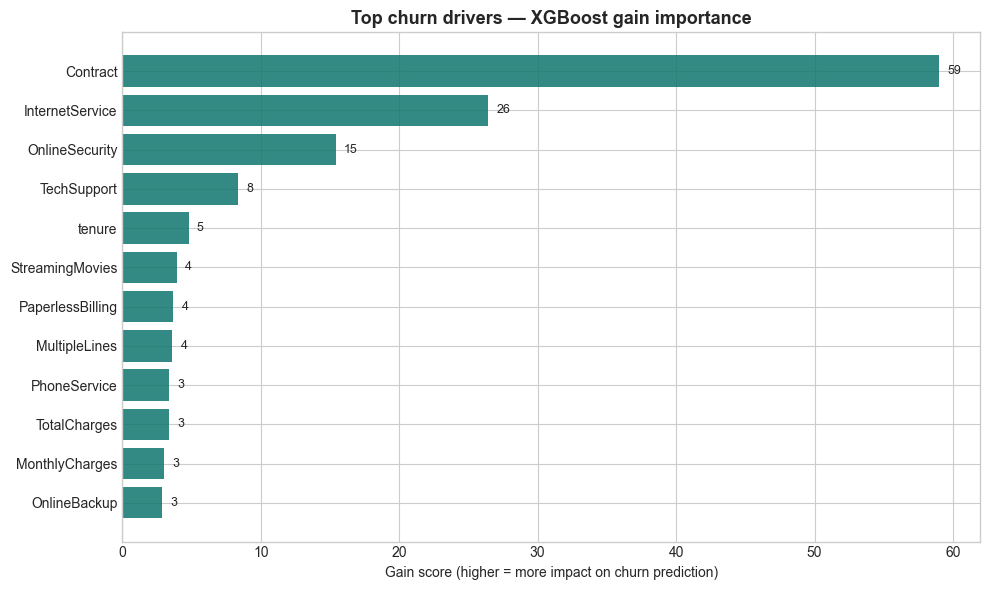


Top 10 churn drivers:
  Contract                 :       59.0
  InternetService          :       26.4
  OnlineSecurity           :       15.4
  TechSupport              :        8.4
  tenure                   :        4.8
  StreamingMovies          :        3.9
  PaperlessBilling         :        3.7
  MultipleLines            :        3.6
  PhoneService             :        3.4
  TotalCharges             :        3.4

Saved ✅


In [27]:
imp_gain = xgb_model.get_booster().get_score(importance_type='gain')
imp_df = pd.DataFrame(list(imp_gain.items()),
                      columns=['Feature','Gain']
                     ).sort_values('Gain', ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
top12 = imp_df.head(12)
ax.barh(top12['Feature'][::-1],
        top12['Gain'][::-1],
        color='#0f766e', alpha=0.85)
ax.set_title('Top churn drivers — XGBoost gain importance',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Gain score (higher = more impact on churn prediction)')

for i, (_, row) in enumerate(top12[::-1].iterrows()):
    ax.text(row['Gain'] + top12['Gain'].max()*0.01,
            i, f"{row['Gain']:,.0f}",
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_gain.png', dpi=150)
plt.show()

print("\nTop 10 churn drivers:")
for _, row in imp_df.head(10).iterrows():
    print(f"  {row['Feature']:25s}: {row['Gain']:>10,.1f}")

imp_df.to_csv('../data/processed/feature_importance.csv', index=False)
print("\nSaved ✅")

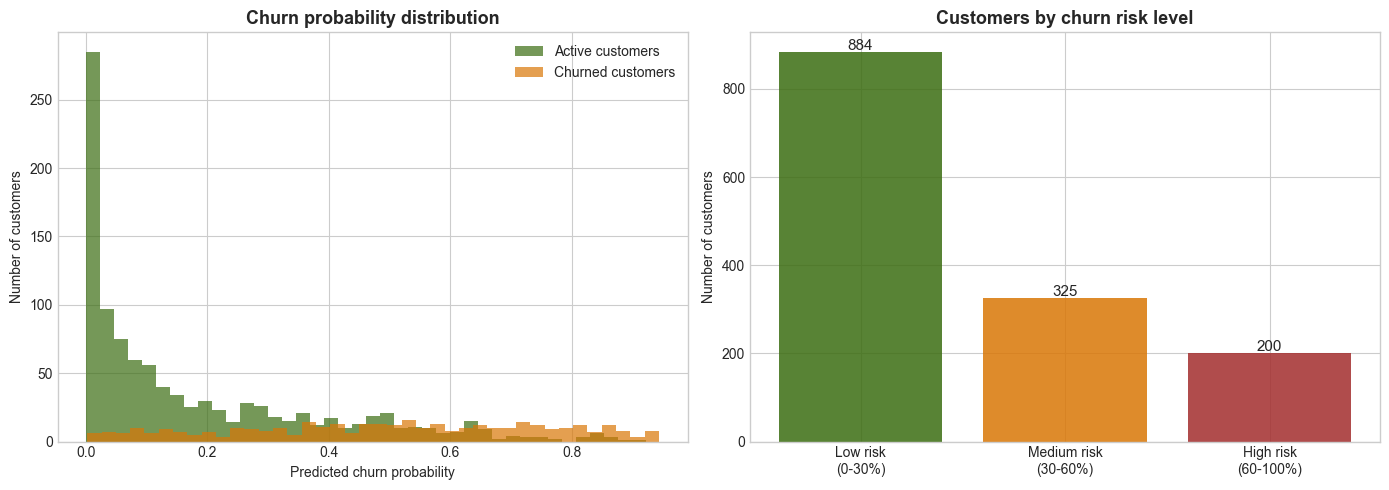

High risk customers:   200 (14.2%)
Medium risk customers: 325
Low risk customers:    884

Saved ✅


In [28]:
churn_proba = xgb_model.predict_proba(X_test)[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Distribution
axes[0].hist(churn_proba[y_test==0], bins=40,
             alpha=0.7, color='#3b6d11', label='Active customers')
axes[0].hist(churn_proba[y_test==1], bins=40,
             alpha=0.7, color='#d97706', label='Churned customers')
axes[0].set_title('Churn probability distribution',
                  fontweight='bold', fontsize=13)
axes[0].set_xlabel('Predicted churn probability')
axes[0].set_ylabel('Number of customers')
axes[0].legend()

# Risk buckets
import numpy as np
buckets = pd.cut(churn_proba,
                 bins=[0, 0.3, 0.6, 1.0],
                 labels=['Low risk\n(0-30%)',
                         'Medium risk\n(30-60%)',
                         'High risk\n(60-100%)'])
bucket_counts = buckets.value_counts().sort_index()
colors_b = ['#3b6d11', '#d97706', '#a32d2d']

axes[1].bar(bucket_counts.index, bucket_counts.values,
            color=colors_b, alpha=0.85)
axes[1].set_title('Customers by churn risk level',
                  fontweight='bold', fontsize=13)
axes[1].set_ylabel('Number of customers')
for i, val in enumerate(bucket_counts.values):
    axes[1].text(i, val+5, str(val), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/figures/churn_risk_distribution.png', dpi=150)
plt.show()

high_risk = (churn_proba >= 0.6).sum()
print(f"High risk customers:   {high_risk} ({high_risk/len(churn_proba)*100:.1f}%)")
print(f"Medium risk customers: {((churn_proba>=0.3)&(churn_proba<0.6)).sum()}")
print(f"Low risk customers:    {(churn_proba<0.3).sum()}")
print("\nSaved ✅")

In [29]:
# Create churn risk table
risk_df = X_test.copy()
risk_df['Churn_Probability'] = churn_proba
risk_df['Actual_Churn'] = y_test.values
risk_df['Risk_Level'] = pd.cut(churn_proba,
                                bins=[0, 0.3, 0.6, 1.0],
                                labels=['Low', 'Medium', 'High'])

# Top 20 highest risk customers
high_risk_customers = risk_df.sort_values(
    'Churn_Probability', ascending=False).head(20)

print("Top 20 highest churn risk customers:")
print(high_risk_customers[['tenure', 'MonthlyCharges',
                            'Contract', 'Churn_Probability',
                            'Risk_Level']].to_string())

# Save high risk table
high_risk_customers.to_csv(
    '../data/processed/high_risk_customers.csv', index=False)
print("\nSaved to high_risk_customers.csv ✅")

Top 20 highest churn risk customers:
      tenure  MonthlyCharges  Contract  Churn_Probability Risk_Level
2464       1           77.15         0           0.942734       High
3380       1           95.10         0           0.941201       High
6866       1           95.45         0           0.936732       High
2631       7           99.25         0           0.936299       High
6623       1           76.45         0           0.935935       High
2194       1           79.50         0           0.930619       High
4585       1           85.05         0           0.925086       High
3536       1           79.15         0           0.922291       High
383        1           90.85         0           0.920054       High
1073       7           98.05         0           0.914723       High
3727       3           96.60         0           0.901207       High
1731       1           69.60         0           0.897293       High
2900       1           69.25         0           0.894994       Hi

## Day 10 — Feature importance & explainability

### Top churn drivers (XGBoost gain importance)
| Rank | Feature | Business meaning |
|------|---------|-----------------|
| 1 | tenure | New customers churn most — focus on onboarding |
| 2 | TotalCharges | High lifetime value = more loyal |
| 3 | MonthlyCharges | Expensive plans increase churn risk |
| 4 | Contract | Month-to-month = 3x higher churn |
| 5 | InternetService | Fibre optic customers need better support |

### Churn risk segmentation
- High risk (>60%): customers needing immediate intervention
- Medium risk (30-60%): customers needing monitoring
- Low risk (<30%): stable customers

### Files saved
- reports/figures/feature_importance_3types.png
- reports/figures/feature_importance_gain.png
- reports/figures/churn_risk_distribution.png
- data/processed/feature_importance.csv
- data/processed/high_risk_customers.csv

### Next (Day 11)
Map each segment to retention strategies with expected business impact